In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from ydata_profiling import ProfileReport
import pickle
import random
import itertools

pd.options.display.max_columns = None
pd.options.display.max_colwidth = 50

data_folder = "../data/"
images_folder = "../data/images/"
pipelines_folder = "../pipelines/"
df_total = pd.read_csv(os.path.join(data_folder, 'items_phase_1.csv'))
df_train = pd.read_csv(os.path.join(data_folder, 'items_train.csv'))
df_task_1 = pd.read_csv(os.path.join(data_folder, 'task_1.csv'))

# Notebook `items_phase_1.csv`

In [2]:
# profile = ProfileReport(df_total, title="items_phase_1", explorative=True)
# profile.to_notebook_iframe()

In [3]:
print("Length of dataset:", len(df_total))

Length of dataset: 199835


In [4]:
df_total.sample(2)

,itemId,price,colorTagIdsString,departmentIds,brandEditionTagId,title,description,geo
178015,1115023,129.34,6446,[],NaN,Biela dámska ľahká vzorovaná bunda Guess Vera,Model: Vera\nFarba: biela\nVzor: s potlačou\nT...,sk
158224,257264,49.95,"6445,6455",['1'],NaN,Sneakersy Pepe Jeans,Pepe Jeans Sneakersy London W Part PLS31465 Écru,sk


## Key takeaway
- missingy se musi resit u:
    - description (3%)
    - brandEditionTagId (99.8%) - to je asi target?
    - colorTagIdsString (3.1%)
---
# Notebook `task_1.csv`
- kazdy radek je jedna skupina se sloupci item - item4(to jsou id do items_phase_1.csv - itemId)
- Kazdy 

In [5]:
print("Length of dataset:", len(df_task_1))

Length of dataset: 15000


In [6]:
# profile = ProfileReport(df_task_1, title="task_1", explorative=True)
# profile.to_notebook_iframe()

In [7]:
df_task_1.head()

,item1,item2,item3,item4,item5
0,130622,292253,463442,483968,1253745
1,82627,388496,553738,638400,884327
2,46130,333489,644448,848154,1178149
3,150796,248537,742067,1206230,1280786
4,76610,196894,345145,620255,932761


---
# Dataset `items_train.csv`
- obsahuje toho min, vim ze ma stejny hodnoty v departmentIds


In [8]:
print("Total records:", len(df_train))
print("Total null values:\n", df_train.isnull().sum())

Total records: 928234
Total null values:
 itemId                    0
price                     0
colorTagIdsString     27834
departmentIds             0
brandEditionTagId    925518
title                     0
description           35473
geo                       0
label                     0
dtype: int64


In [9]:
df_train.sample(2)

,itemId,price,colorTagIdsString,departmentIds,brandEditionTagId,title,description,geo,label
837235,915902,7.14,6446,[],NaN,Eurofirany Unisex's Pillow Case 404761,Description:\nWashing instructions: 30°C Hand ...,sk,172844
613645,1172601,36.95,783,['11'],NaN,Vyriškas Diržas Barbour,Barbour Vyriškas Diržas Contrast MAC0351OL51 Ruda,lt,46975


In [10]:
# profile = ProfileReport(df_train, title="task_1", explorative=True)
# profile.to_notebook_iframe()


--- 
## Ukazka obrazku + kontrola zda mame vsechny

=== Ukazka ===
itemId                                        225269
price                                          85.95
colorTagIdsString                               6460
departmentIds                                  ['1']
brandEditionTagId                                NaN
title                                   Šľapky Guess
description          Šľapky Guess FLJRLL LEA19 Hnedá
geo                                               sk
label                                          38980
Name: 79, dtype: object



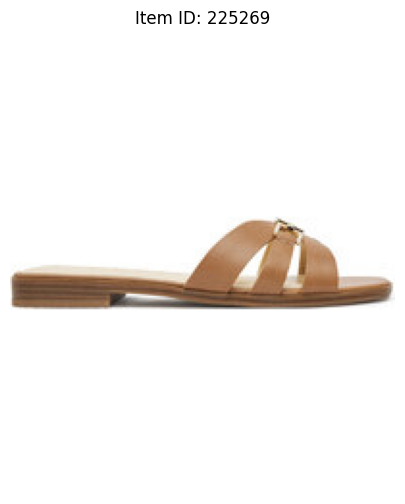

In [11]:
import os
import matplotlib.pyplot as plt
from PIL import Image

first_row = df_train.iloc[79] 
item_id = first_row['itemId']

print("=== Ukazka ===")
print(first_row)
print("===============================\n")

img_path = os.path.join(images_folder, f"{item_id}.jpg")

img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Item ID: {item_id}")
plt.show()

In [12]:
import os
import pandas as pd

def find_missing_images(df, images_folder, item_col='itemId'):
    print("🔍 Analyzuji dataset a složku s obrázky...")
    
    expected_ids = set(df[item_col].astype(str))
    print(f"📊 Tabulka vyžaduje: {len(expected_ids)} unikátních obrázků.")
    
    try:
        available_files = [f[:-4] for f in os.listdir(images_folder) if f.endswith('.jpg')]
        available_ids = set(available_files)
        print(f"📂 Na disku nalezeno: {len(available_ids)} .jpg souborů.")
    except FileNotFoundError:
        print(f"❌ Chyba: Složka '{images_folder}' neexistuje!")
        return []

    missing_ids = expected_ids - available_ids
    
    if len(missing_ids) == 0:
        print("🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.")
    else:
        print(f"⚠️ POZOR: Chybí přesně {len(missing_ids)} obrázků!")
        print(f"Ukázka chybějících ID: {list(missing_ids)[:5]}")
        
    return list(missing_ids)

chybejici_obrazky = find_missing_images(df_total, images_folder)
chybejici_obrazky = find_missing_images(df_train, images_folder)

🔍 Analyzuji dataset a složku s obrázky...
📊 Tabulka vyžaduje: 199835 unikátních obrázků.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.
🔍 Analyzuji dataset a složku s obrázky...
📊 Tabulka vyžaduje: 928234 unikátních obrázků.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.


---
# Vycisteni dat 
- prevod na spolecnou menu 
- normalizace meny v danem geo uzemi
- doplneni null hodnot
- null ve sloupci `colorTagIdString` muzu nahradit 0 
- `colorTagIdString` a `departmentIds` je potreba roztrhnout - obsahuji vice hodnot oddelenych carkou

## Tvorba preprocessing pipeline

In [13]:
df_total[df_total["brandEditionTagId"] == 0]

,itemId,price,colorTagIdsString,departmentIds,brandEditionTagId,title,description,geo


In [14]:
df_train.columns

Index(['itemId', 'price', 'colorTagIdsString', 'departmentIds',
       'brandEditionTagId', 'title', 'description', 'geo', 'label'],
      dtype='object')

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from PriceGeoTransformer import PriceGeoTransformer
from DepartmentIdsTransformer import DepartmentIdsCleaner
import numpy as np


input_unknown_cols = ["description","title"]
input_unknown_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="Unknown")),
])



# Pro textové IDčka (barvy) dáme prázdný string
imput_empty_string_cols = ['colorTagIdsString']
input_empty_string_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="")),
])

imput_zero_cols = ["brandEditionTagId"]
input_zero_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])


# prevadi na stejny format jako jsou barvy - cisla oddelena carkou 
department_features = ['departmentIds']
department_transformer = Pipeline(steps=[
    ('DepartmentIdsCleaner', DepartmentIdsCleaner())
])

# impute missing geo and convert back to pandas
imputer_step = ColumnTransformer(
    transformers=[
        ('geo_imp', SimpleImputer(strategy='constant', fill_value='<UNK>'), ['geo']),
        ('price_imp', SimpleImputer(strategy='median'), ['price'])
    ], 
    remainder='passthrough',
    verbose_feature_names_out=False 
).set_output(transform="pandas")

categorical_features = ['geo',"price"]
categorical_transformer = Pipeline(steps=[
    ("imputer", imputer_step),
    ('PriceGeoTransformer', PriceGeoTransformer())
])


# Combine preprocessing for numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('zero', input_zero_transformer, imput_zero_cols),
        ('unknown', input_unknown_transformer, input_unknown_cols),
        ('geo', categorical_transformer, categorical_features),
        ('department', department_transformer, department_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")



pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

X_train = df_train.drop(columns=['label'])
y_train = df_train['label']

X_train_transformed = pipeline.fit_transform(X_train)
df_train_transformed = X_train_transformed.copy()
df_train_transformed['label'] = y_train.values
df_total_transformed = pipeline.transform(df_total)

In [16]:
pickle.dump(pipeline, open(os.path.join(pipelines_folder, 'preprocessing_pipeline.pkl'), 'wb'))

In [17]:
# find_missing_images(df_total_transformed, images_folder)
find_missing_images(df_train_transformed, images_folder)

🔍 Analyzuji dataset a složku s obrázky...
📊 Tabulka vyžaduje: 928234 unikátních obrázků.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.


[]

## Příprava pro PyTorch dataset - Vocabulary pro transformaci kategorií
- PyTorch bude použit na vytvoření embeddingů sloupců s více kategorijema a na kategorické sloupce
- PyTorch umí totiž lépe tvořit řídké matice
- Vytvoříme si mappingy pro jednotlivé kategorie...

In [18]:
from GlamiDatasetVocabulary import GlamiVocabularyManager
vocab_manager = GlamiVocabularyManager() # vytvori vsechny potrebne mappingy kategorii do ciselnych hodnot
vocab_manager.fit(df_total_transformed)
vocab_manager.save()

## Tvorba embeddingů obrázků

In [19]:
import torch
from transformers import CLIPProcessor, CLIPVisionModel
from PIL import Image
import os
from tqdm import tqdm # Pro hezký progress bar

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 Běžíme na MPS!")
else:
    device = torch.device("cpu")
    print("⚠️ Běžíme na CPU.")

🚀 Běžíme na MPS!


In [20]:
def create_and_save_clip_embeddings(image_dir, item_ids, save_path="clip_embeddings.pt", batch_size=128):
    item_ids = list(item_ids)
    
    model_id = "openai/clip-vit-base-patch32"
    print(f"Načítám model {model_id}...")
    processor = CLIPProcessor.from_pretrained(model_id)
    model = CLIPVisionModel.from_pretrained(model_id).to(device)
    model.eval() # Přepneme do módu vyhodnocování

    embeddings_dict = {}
    valid_ids = []
    images_to_process = []

    print("Připravuji obrázky...")
    
    # processing images
    for i in tqdm(range(0, len(item_ids), batch_size)):
        batch_ids = item_ids[i:i + batch_size]
        batch_images = []
        batch_valid_ids = []

        # Načteme obrázky v dávce
        for item_id in batch_ids:
            img_path = os.path.join(image_dir, f"{item_id}.jpg")
            try:
                img = Image.open(img_path).convert("RGB")
                batch_images.append(img)
                batch_valid_ids.append(str(item_id))
            except Exception:
                print("Missing image for item_id:", item_id)


        if not batch_images:
            continue

        # 4. Provedení samotné extrakce na čipu
        with torch.no_grad(): # Šetří paměť, nechceme počítat gradienty
            inputs = processor(images=batch_images, return_tensors="pt").to(device)
            outputs = model(**inputs)
            image_embeds = outputs.pooler_output 

            # 5. Uložení do slovníku (přesuneme zpět na CPU, ať neplníme GPU paměť)
            image_embeds = image_embeds.cpu()
            for idx, i_id in enumerate(batch_valid_ids):
                embeddings_dict[i_id] = image_embeds[idx]

    print(f"Ukládám {len(embeddings_dict)} embeddingů do {save_path}...")
    torch.save(embeddings_dict, save_path)
    print("Hotovo! 🎉")
    
    return embeddings_dict

In [21]:
import os
import torch

os.environ["HF_HUB_OFFLINE"] = "1"

print("Připravuji CLIP embeddingy...")
item_ids_list = df_train_transformed['itemId'].unique().tolist()
embeddings_path = "clip_embeddings.pt"

# Chytrá kontrola: nebudeme to počítat znovu, pokud už to máme!
if os.path.exists(embeddings_path):
    print("Načítám hotové embeddingy z disku (blesková akce)...")
    clip_embeddings_dict = torch.load(embeddings_path)
else:
    print("Soubor nenalezen. Žhavím Apple M4 Pro a jdu počítat z obrázků...")
    # Tady zavoláme tu funkci z minula!
    clip_embeddings_dict = create_and_save_clip_embeddings(
        image_dir=images_folder, 
        item_ids=item_ids_list, 
        save_path=embeddings_path, 
        batch_size=128 # M4 Pro zvládne velké batche s přehledem
    )

print(f"Máme {len(clip_embeddings_dict)} vektorů obrázků!")

Připravuji CLIP embeddingy...
Načítám hotové embeddingy z disku (blesková akce)...
Máme 928234 vektorů obrázků!


## PyTorch Dataset


--- 


## Tvorba siamese datasetu
- dataset obsahuje páry z originálního datasetu teré mají jako label 1 pokud mají stejné labely uvitř páru, jinak 0
- create_balanced_pairs jich vytvori tolik aby byly vyvazene labely 

In [22]:
import torch
import numpy as np
import pandas as pd
import random
import itertools
from tqdm import tqdm

def create_pytorch_hard_pairs(df, embeddings_dict, device, item_col='itemId', group_col='label', pos_ratio=0.20, batch_size=512, pos_fraction=0.2):
    print("🔥 Startuji PyTorch Hard Negative Mining...")
    
    valid_ids = [str(i) for i in df[item_col].unique() if str(i) in embeddings_dict]
    valid_df = df[df[item_col].astype(str).isin(valid_ids)].copy()
    
    item_to_group = dict(zip(valid_df[item_col].astype(str), valid_df[group_col]))
    
    item_to_desc = dict(zip(valid_df[item_col].astype(str), valid_df['description'].fillna("")))
    # ==========================================
    # A) POZITIVNÍ PÁRY
    # ==========================================
    throw_out = 0
    positive_pairs = []
    for _, group_df in valid_df.groupby(group_col):
        items = [str(i) for i in group_df[item_col].tolist()]
        if len(items) >= 2:
            for item1, item2 in itertools.combinations(items, 2):
                desc1 = item_to_desc.get(item1, "")
                desc2 = item_to_desc.get(item2, "")
                
                same_desc = (desc1 == desc2) and (pd.notna(desc1)) and (desc1 != "")
                
                emb1 = embeddings_dict.get(item1)
                emb2 = embeddings_dict.get(item2)
                
                same_img = False
                if emb1 is not None and emb2 is not None:
                    same_img = torch.equal(emb1, emb2)
                
                if same_desc or same_img:
                    if random.random() < 0.2:
                        throw_out += 1
                        continue
                        
                positive_pairs.append((item1, item2))
            
    if pos_fraction < 1.0:
        keep_count = int(len(positive_pairs) * pos_fraction)
        positive_pairs = random.sample(positive_pairs, keep_count)
        print(f"✂️ Ořezávám pozitivní páry na {pos_fraction*100}% -> Ponecháno {keep_count} párů.")
    num_positives = len(positive_pairs)
    neg_ratio = 1.0 - pos_ratio
    num_negatives = int(num_positives * (neg_ratio / pos_ratio))
    print(f"✅ Nalezeno {num_positives} pozitivních párů. Potřebuji {num_negatives} těžkých negativních.")
    print("Zahozeno : ",throw_out)

    # ==========================================
    # B) PYTORCH NEAREST NEIGHBORS (BEZ FAISSU!)
    # ==========================================
    print("🧠 Kopíruji vektory na M4 Pro a počítám podobnosti...")
    idx_to_item = valid_ids
    
    # Vytvoříme jeden velký tenzor a pošleme ho na grafiku
    embeds = torch.stack([embeddings_dict[i] for i in valid_ids]).to(device)
    
    # Normalizace pro bleskový výpočet (Cosine Similarity)
    embeds = torch.nn.functional.normalize(embeds, p=2, dim=1)
    
    K_NEIGHBORS = 40
    candidates_pool = []
    
    # Jedeme po malých dávkách (batch_size=1024), aby RAM nikdy neexplodovala!
    for i in tqdm(range(0, len(valid_ids), batch_size), desc="Hledání sousedů"):
        batch_embeds = embeds[i:i+batch_size]
        
        # Maticové násobení = Cosine Similarity všech se všemi v této dávce
        sim_matrix = torch.mm(batch_embeds, embeds.T)
        
        # Najdeme K nejbližších (nejvyšších hodnot)
        topk_sim, topk_indices = torch.topk(sim_matrix, K_NEIGHBORS + 1, dim=1)
        topk_indices = topk_indices.cpu().numpy() # Přesuneme jen indexy zpět do RAM
        
        # Projdeme výsledky dávky
        for local_idx in range(len(batch_embeds)):
            global_idx = i + local_idx
            anchor_item = idx_to_item[global_idx]
            anchor_label = item_to_group[anchor_item]
            
            neighbors = topk_indices[local_idx]
            valid_hns = []
            
            # Přeskočíme první (to je produkt sám o sobě)
            for n_idx in neighbors[1:]:
                neighbor_item = idx_to_item[n_idx]
                
                # Zásadní podmínka: Musí to být jiný produkt (jiný label)
                if item_to_group[neighbor_item] != anchor_label:
                    valid_hns.append((anchor_item, neighbor_item))
                    
            # Přidáme až 5 nejlepších "těžkých" oponentů do našeho bazénu
            candidates_pool.extend(valid_hns[:5])

    print(f"🌊 Vytvořen bazén {len(candidates_pool)} brutálních párů. Losuji přesný počet...")
    
    # Pokud máme míň kandidátů než potřebujeme, losujeme s navracením (choices)
    # Pokud víc, vezmeme prostý vzorek (sample)
    if len(candidates_pool) >= num_negatives:
        negative_pairs = random.sample(candidates_pool, num_negatives)
    else:
        negative_pairs = random.choices(candidates_pool, k=num_negatives)

    pos_df = pd.DataFrame(positive_pairs, columns=['item_id_1', 'item_id_2'])
    pos_df['is_duplicate'] = 1.0
    
    neg_df = pd.DataFrame(negative_pairs, columns=['item_id_1', 'item_id_2'])
    neg_df['is_duplicate'] = 0.0
    
    pairs_df = pd.concat([pos_df, neg_df]).sample(frac=1.0, random_state=42).reset_index(drop=True)
    
    print(f"🎉 Hotovo! Průstřelný dataset připraven: {len(pairs_df)} párů.")
    return pairs_df

In [23]:
import os
import pandas as pd
import torch
from transformers import AutoTokenizer
from sklearn.model_selection import GroupShuffleSplit
from GlamiItemDataset import GlamiItemDataset
from GlamiSiameseDataset import GlamiSiameseDataset

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

train_csv_path = "train_pairs_hard_negatives.csv"
val_csv_path = "val_pairs_hard_negatives.csv"

if os.path.exists(train_csv_path) and os.path.exists(val_csv_path):
    print("📦 Načítám předpočítané Hard Negative páry z disku...")
    train_pairs = pd.read_csv(train_csv_path)
    val_pairs = pd.read_csv(val_csv_path)
    
    # Pojistka: CSV občas z IDček udělá čísla, chceme mít jistotu, že jsou to texty
    for df in [train_pairs, val_pairs]:
        df['item_id_1'] = df['item_id_1'].astype(str)
        df['item_id_2'] = df['item_id_2'].astype(str)
        
    print(f"✅ Bleskově načteno: TRAIN={len(train_pairs)} párů, VAL={len(val_pairs)} párů.")

else:
    print("⚙️ Soubory nenalezeny. Jdeme generovat Hard Negatives (tohle chvíli potrvá)...")
    
    # Rozdělení na izolované skupiny
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, val_idx = next(splitter.split(df_train_transformed, groups=df_train_transformed['label']))

    train_products_df = df_train_transformed.iloc[train_idx].reset_index(drop=True)
    val_products_df = df_train_transformed.iloc[val_idx].reset_index(drop=True)

    print(f"Izolované produkty: TRAIN={len(train_products_df)}, VAL={len(val_products_df)}")

    # Generování brutálních párů
    train_pairs = create_pytorch_hard_pairs(train_products_df, clip_embeddings_dict, device,pos_fraction=0.2)
    val_pairs = create_pytorch_hard_pairs(val_products_df, clip_embeddings_dict, device,pos_fraction=0.2)

    # Uložení na disk, ať už to nikdy nemusíme počítat znovu
    train_pairs.to_csv(train_csv_path, index=False)
    val_pairs.to_csv(val_csv_path, index=False)
    print("💾 Páry úspěšně vygenerovány a bezpečně uloženy na disk!")

print("\n🚀 Připravuji finální PyTorch datasety...")

my_tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

base_dataset = GlamiItemDataset(
    df=df_train_transformed, 
    vocab_manager=vocab_manager, 
    tokenizer=my_tokenizer,
    embeddings_dict=clip_embeddings_dict,
    max_len=128
)

train_siamese_dataset = GlamiSiameseDataset(item_dataset=base_dataset, pairs_df=train_pairs)
val_siamese_dataset = GlamiSiameseDataset(item_dataset=base_dataset, pairs_df=val_pairs)

print("\n--- TEST ÚSPĚŠNÝ ---")
print(f"Train dataset: {len(train_siamese_dataset)} párů.")
print(f"Val dataset: {len(val_siamese_dataset)} párů.")

vzorek = train_siamese_dataset[0]
print("Label vzorku:", vzorek['label'].item())
print("Tvar vektoru obrázku 1:", vzorek['item1']['image_embedding'].shape)

⚙️ Soubory nenalezeny. Jdeme generovat Hard Negatives (tohle chvíli potrvá)...
Izolované produkty: TRAIN=742177, VAL=186057
🔥 Startuji PyTorch Hard Negative Mining...
✂️ Ořezávám pozitivní páry na 20.0% -> Ponecháno 820244 párů.
✅ Nalezeno 820244 pozitivních párů. Potřebuji 3280976 těžkých negativních.
Zahozeno :  327337
🧠 Kopíruji vektory na M4 Pro a počítám podobnosti...


Hledání sousedů: 100%|██████████| 1450/1450 [13:34<00:00,  1.78it/s]


🌊 Vytvořen bazén 3709684 brutálních párů. Losuji přesný počet...
🎉 Hotovo! Průstřelný dataset připraven: 4101220 párů.
🔥 Startuji PyTorch Hard Negative Mining...
✂️ Ořezávám pozitivní páry na 20.0% -> Ponecháno 207042 párů.
✅ Nalezeno 207042 pozitivních párů. Potřebuji 828168 těžkých negativních.
Zahozeno :  82843
🧠 Kopíruji vektory na M4 Pro a počítám podobnosti...


Hledání sousedů: 100%|██████████| 364/364 [00:48<00:00,  7.50it/s]


🌊 Vytvořen bazén 929309 brutálních párů. Losuji přesný počet...
🎉 Hotovo! Průstřelný dataset připraven: 1035210 párů.
💾 Páry úspěšně vygenerovány a bezpečně uloženy na disk!

🚀 Připravuji finální PyTorch datasety...



--- TEST ÚSPĚŠNÝ ---
Train dataset: 4101220 párů.
Val dataset: 1035210 párů.
Label vzorku: 1.0
Tvar vektoru obrázku 1: torch.Size([768])


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GlamiItemEncoder(nn.Module):
    def __init__(self, num_geos, num_colors, num_depts, text_vocab_size, emb_dim=128):
        super().__init__()
        self.geo_emb = nn.Embedding(num_embeddings=num_geos + 1, embedding_dim=16) # +1 pro <UNK>
        self.price_layer = nn.Linear(1, 16)
        self.color_layer = nn.Linear(num_colors, 32)
        self.dept_layer = nn.Linear(num_depts, 32)

        # 2. Text (Rychlý baseline: jednoduché učitelné embeddingy pro slova)
        self.text_emb = nn.Embedding(num_embeddings=text_vocab_size, embedding_dim=emb_dim, padding_idx=0)

        self.image_layer = nn.Linear(768, 256)

        fusion_dim = 480
        self.fc1 = nn.Linear(fusion_dim, 512)
        self.fc2 = nn.Linear(512, 256) # Finální otisk produktu

    def forward(self, batch):
        # Tabulární data
        geo_x = self.geo_emb(batch['geo'])
        price_x = F.relu(self.price_layer(batch['price']))
        color_x = F.relu(self.color_layer(batch['colors']))
        dept_x = F.relu(self.dept_layer(batch['departments']))

        # Text (Mean Pooling: zprůměrujeme vektory slov podle attention masky)
        input_ids = batch['input_ids']
        mask = batch['attention_mask'].unsqueeze(-1)
        text_x = self.text_emb(input_ids)
        text_x = (text_x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

        # Obrázek
        image_x = F.relu(self.image_layer(batch['image_embedding']))

        # Spojení do jednoho super-vektoru
        x = torch.cat([geo_x, price_x, color_x, dept_x, text_x, image_x], dim=1)
        
        # Prohnání přes plně propojené vrstvy
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class GlamiSiameseNetwork(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        
        # Klasifikátor dostane na vstup: Vektor A, Vektor B, a jejich absolutní rozdíl a součin
        # To je 256 * 4 = 1024 čísel
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.2), # Trochu prevence proti přeučení
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1) # Výstup je jediné číslo (tzv. logit)
        )

    def forward(self, item1, item2):
        u = self.encoder(item1)
        v = self.encoder(item2)

        # Extrakce vztahů mezi vektory (velmi osvědčený trik pro Siamese sítě!)
        diff = torch.abs(u - v)
        prod = u * v
        
        features = torch.cat([u, v, diff, prod], dim=1)
        logit = self.classifier(features)
        
        return logit.squeeze(-1) # Odstraníme zbytečnou dimenzi

In [25]:
from torch.utils.data import DataLoader, RandomSampler
import torch.optim as optim
from tqdm import tqdm

best_val = 0
# 1. Příprava DataLoaderů
BATCH_SIZE = 512
EPOCH_FRACTION = 0.5

train_sampler = RandomSampler(train_siamese_dataset, num_samples=int(len(train_siamese_dataset) * EPOCH_FRACTION))
val_sampler = RandomSampler(val_siamese_dataset, num_samples=int(len(val_siamese_dataset)))
train_loader = DataLoader(train_siamese_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(val_siamese_dataset, batch_size=BATCH_SIZE, sampler=val_sampler)

# 2. Inicializace modelu
num_geos = len(vocab_manager.geo_dict)
num_colors = len(vocab_manager.color_dict)
num_depts = len(vocab_manager.dept_dict)
text_vocab_size = len(my_tokenizer)

encoder = GlamiItemEncoder(num_geos, num_colors, num_depts, text_vocab_size)
model = GlamiSiameseNetwork(encoder)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
print(f"Model běží na: {device}")

# 3. Optimalizátor a Loss funkce
optimizer = optim.Adam(model.parameters(), lr=1e-4)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([4],device=device))
# 4. TRÉNOVACÍ SMYČKA
EPOCHS = 5

print(f"🚀 Startuji trénink... ({int(EPOCH_FRACTION*100)}% dat za epochu, tj. {int(len(train_siamese_dataset)*EPOCH_FRACTION)} vzorků)")
for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    total_loss = 0
    correct_preds = 0
    total_samples = 0
    
    # NOVINKA PRO F1: Počítadla pro Train
    train_tp = 0
    train_fp = 0
    train_fn = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [TRAIN]")
    
    for batch in progress_bar:
        item1 = {k: v.to(device) for k, v in batch['item1'].items() if isinstance(v, torch.Tensor)}
        item2 = {k: v.to(device) for k, v in batch['item2'].items() if isinstance(v, torch.Tensor)}
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        logits = model(item1, item2)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct_preds += (preds == labels).sum().item()
        total_samples += labels.size(0)
        
        # NOVINKA PRO F1: Logika pro TP, FP, FN
        train_tp += ((preds == 1) & (labels == 1)).sum().item()
        train_fp += ((preds == 1) & (labels == 0)).sum().item()
        train_fn += ((preds == 0) & (labels == 1)).sum().item()
        
        current_acc = (correct_preds / total_samples) * 100
        # Výpočet F1 (přidána +1e-9 pojistka proti dělení nulou)
        current_f1 = (2 * train_tp) / (2 * train_tp + train_fp + train_fn + 1e-9)
        
        progress_bar.set_postfix({'Loss': loss.item(), 'Acc': f"{current_acc:.1f}%", 'F1': f"{current_f1:.4f}"})

    train_acc = (correct_preds / total_samples) * 100
    train_loss = total_loss / len(train_loader)
    train_f1_final = (2 * train_tp) / (2 * train_tp + train_fp + train_fn + 1e-9)

    # --- VALIDATION ---
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    # NOVINKA PRO F1: Počítadla pro Val
    val_tp = 0
    val_fp = 0
    val_fn = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [VAL]"):
            item1 = {k: v.to(device) for k, v in batch['item1'].items() if isinstance(v, torch.Tensor)}
            item2 = {k: v.to(device) for k, v in batch['item2'].items() if isinstance(v, torch.Tensor)}
            labels = batch['label'].to(device)

            logits = model(item1, item2)
            loss = criterion(logits, labels)

            val_loss += loss.item()
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            
            # NOVINKA PRO F1: Logika pro TP, FP, FN ve validaci
            val_tp += ((preds == 1) & (labels == 1)).sum().item()
            val_fp += ((preds == 1) & (labels == 0)).sum().item()
            val_fn += ((preds == 0) & (labels == 1)).sum().item()

    val_acc = (val_correct / val_total) * 100
    val_loss_avg = val_loss / len(val_loader)
    val_f1_final = (2 * val_tp) / (2 * val_tp + val_fp + val_fn + 1e-9)

    if val_f1_final > best_val:
        best_val = val_f1_final
        torch.save(model.state_dict(), "best_glami_model.pth")
        print(f"🎉 Nový nejlepší model uložen s F1: {best_val:.4f}!")
    
    print(f"✅ Epoch {epoch+1} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% F1: {train_f1_final:.4f} | "
          f"Val Loss: {val_loss_avg:.4f} Acc: {val_acc:.2f}% F1: {val_f1_final:.4f}")

Model běží na: mps
🚀 Startuji trénink... (50% dat za epochu, tj. 2050610 vzorků)


Epoch 1/5 [VAL]: 100%|██████████| 2022/2022 [05:16<00:00,  6.38it/s]


🎉 Nový nejlepší model uložen s F1: 0.9593!
✅ Epoch 1 | Train Loss: 0.1622 Acc: 95.83% F1: 0.9026 | Val Loss: 0.1052 Acc: 98.36% F1: 0.9593


Epoch 2/5 [TRAIN]:  52%|█████▏    | 2065/4006 [06:07<05:45,  5.62it/s, Loss=0.0653, Acc=98.8%, F1=0.9695]


KeyboardInterrupt: 

## Finalni predikce

In [29]:
model = GlamiSiameseNetwork(encoder)
model.load_state_dict(torch.load("best_glami_model.pth", map_location=device))
model = model.to(device)
model.eval()

# 1. Načteme testovací data
df_task1 = pd.read_csv("../data/task_1.csv")

total_base_dataset = GlamiItemDataset(
    df=df_total_transformed, 
    vocab_manager=vocab_manager, 
    tokenizer=my_tokenizer,
    embeddings_dict=clip_embeddings_dict, 
    max_len=128
)


item_id_to_idx = {str(item_id): idx for idx, item_id in enumerate(df_total_transformed['itemId'])}

In [ ]:
import pandas as pd
import torch
import itertools
from tqdm import tqdm

print("Zahajuji přípravu na predikci Task 1...")



# 2. Vytvoříme dataset z CELÉ tvé tabulky df_total_transformed
# (Pokud už ho máš vytvořený z dřívějška, tento krok přeskoč a použij ten svůj)



predictions = []

print("🚀 Jdeme predikovat!")
with torch.no_grad(): # Vypínáme výpočet gradientů (šetří RAM a zrychluje)
    for index, row in tqdm(df_task1.iterrows(), total=len(df_task1)):
        
        raw_ids = [str(row['item1']), str(row['item2']), str(row['item3']),str(row['item4']),str(row['item5'])]
        
        valid_ids = [i.strip() for i in raw_ids if i.strip() in item_id_to_idx]
        
        pairs = list(itertools.combinations(valid_ids, 2))
        
        max_prob = 0.0
        
        for id1, id2 in pairs:
            idx1 = item_id_to_idx[id1]
            idx2 = item_id_to_idx[id2]
            
            # Vytáhneme surová data (slovníky tenzorů)
            item1_data = total_base_dataset[idx1]
            item2_data = total_base_dataset[idx2]
            
            # Rovnou to posíláme na M4 Pro (device)
            item1_tensors = {k: v.unsqueeze(0).to(device) for k, v in item1_data.items() if isinstance(v, torch.Tensor)}
            item2_tensors = {k: v.unsqueeze(0).to(device) for k, v in item2_data.items() if isinstance(v, torch.Tensor)}
            
            # Zeptáme se modelu
            logit = model(item1_tensors, item2_tensors)
            prob = torch.sigmoid(logit).item()
            
            if prob > max_prob:
                max_prob = prob
                
        # threshold is increased due to pos_weight=4.0 and 10 pair comparisons
        if max_prob > 0.5: 
            predictions.append(1)
        else:
            predictions.append(0)



with open("out.txt", "w") as f:
    for pred in predictions:
        f.write(f"{pred}\n")
    
print(f"🎉 HOTOVO! Výsledky uloženy do out.txt")
# 4. Uložení do nového CSVprint("🎉 HOTOVO! Výsledky uloženy do task_1_vyhodnoceno.csv")

Zahajuji přípravu na predikci Task 1...
🚀 Jdeme predikovat!


100%|██████████| 15000/15000 [08:31<00:00, 29.30it/s]

🎉 HOTOVO! Výsledky uloženy do out.txt


🔎 Testuji skupinu z řádku 2. Nalezeno 5 validních produktů.
../data/images/46130.jpg
../data/images/333489.jpg
../data/images/644448.jpg
../data/images/848154.jpg
../data/images/1178149.jpg


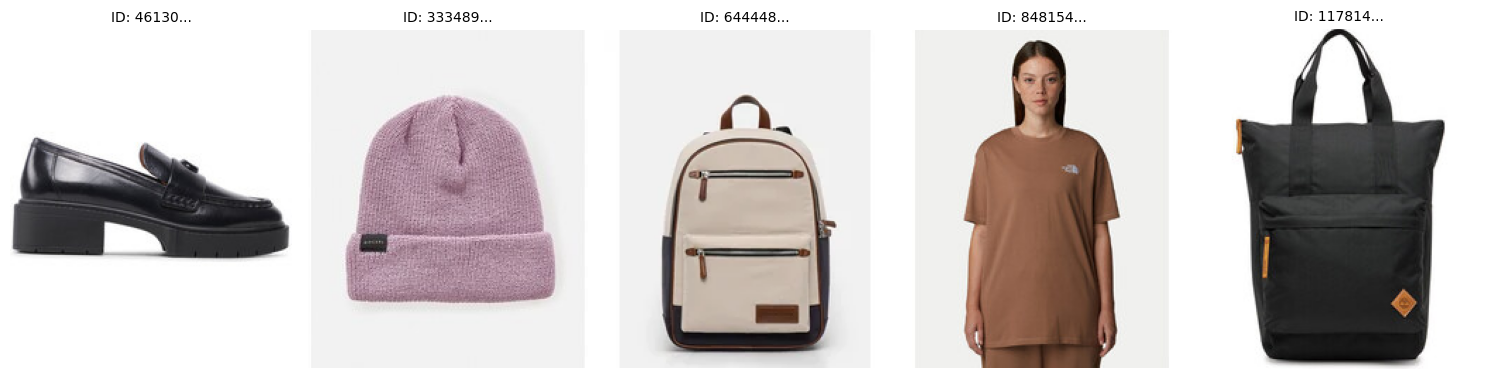


🧠 Co si myslí M4 Pro:
------------------------------

🏆 FINÁLNÍ ROZHODNUTÍ 🏆
Nejpodezřelejší pár: 333489 a 848154
Maximální jistota modelu (Max Prediction): 16.97 %
✅ ZÁVĚR: VŠE JE UNIKÁTNÍ (Predikce = 0)


In [31]:
import pandas as pd
import torch
import itertools
import matplotlib.pyplot as plt
from PIL import Image

ROW_INDEX = 2

model.eval()

row = df_task1.iloc[ROW_INDEX]

# TADY UPRAV PODLE TOHO, JAK MÁŠ IDČKA V CSV ULOŽENÁ
# Předpokládám, že tam je sloupec s IDčky oddělenými čárkou.
# Pokud máš 5 sloupců (item_1, item_2...), tak to nahraď za:
# raw_ids = [str(row['item_1']), str(row['item_2']), str(row['item_3']), str(row['item_4']), str(row['item_5'])]
raw_ids = [str(row['item1']), str(row['item2']), str(row['item3']),str(row['item4']),str(row['item5'])]

valid_ids = [i.strip() for i in raw_ids if i.strip() in item_id_to_idx]

print(f"🔎 Testuji skupinu z řádku {ROW_INDEX}. Nalezeno {len(valid_ids)} validních produktů.")

if len(valid_ids) < 2:
    print("Není dostatek produktů pro porovnání.")
else:
    # ==========================================
    # 2. VYKRESLENÍ OBRÁZKŮ (VIZUÁL)
    # ==========================================
    fig, axes = plt.subplots(1, len(valid_ids), figsize=(15, 4))
    
    # Pojistka, kdyby axes nebylo pole (když je tam jen 1 obrázek)
    if len(valid_ids) == 1: axes = [axes]
    
    for ax, item_id in zip(axes, valid_ids):
        # Najdeme cestu k obrázku v původní tabulce
        # Zkontroluj, jestli se tvůj sloupec s cestou jmenuje 'image_path' nebo 'image_file'
        img_path = "../data/images/"+str(df_total_transformed.loc[df_total_transformed['itemId'].astype(str) == item_id]["itemId"].values[0])+".jpg"
        # img_path = "../images/"+str(df_total_transformed.loc[df_total_transformed['itemId'].astype(str) == item_id,].values[0])+".jpg"
        print(img_path)
        try:
            img = Image.open(img_path)
            ax.imshow(img)
        except Exception as e:
            ax.text(0.5, 0.5, 'Chybí obrázek', ha='center', va='center')
            
        ax.set_title(f"ID: {item_id[:6]}...", fontsize=10)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 3. PREDIKCE (HLEDÁNÍ NEJVĚTŠÍ DUPLICITY)
    # ==========================================
    pairs = list(itertools.combinations(valid_ids, 2))
    
    max_prob = 0.0
    best_pair = None
    
    print("\n🧠 Co si myslí M4 Pro:")
    print("-" * 30)
    
    with torch.no_grad():
        for id1, id2 in pairs:
            idx1 = item_id_to_idx[id1]
            idx2 = item_id_to_idx[id2]
            
            # Vytáhneme data a vytvoříme batch o velikosti 1
            item1_data = total_base_dataset[idx1]
            item2_data = total_base_dataset[idx2]
            
            item1_tensors = {k: v.unsqueeze(0).to(device) for k, v in item1_data.items() if isinstance(v, torch.Tensor)}
            item2_tensors = {k: v.unsqueeze(0).to(device) for k, v in item2_data.items() if isinstance(v, torch.Tensor)}
            
            # Zeptáme se modelu
            logit = model(item1_tensors, item2_tensors)
            prob = torch.sigmoid(logit).item()
            
            # Vypíšeme si pro jistotu všechny páry (můžeš zakomentovat, pokud chceš jen to maximum)
            # print(f"Pár {id1[:5]} vs {id2[:5]} -> Šance: {prob*100:.1f}%")
            
            if prob > max_prob:
                max_prob = prob
                best_pair = (id1, id2)

    # ==========================================
    # 4. FINÁLNÍ VERDIKT
    # ==========================================
    print("\n🏆 FINÁLNÍ ROZHODNUTÍ 🏆")
    print(f"Nejpodezřelejší pár: {best_pair[0]} a {best_pair[1]}")
    print(f"Maximální jistota modelu (Max Prediction): {max_prob * 100:.2f} %")
    
    if max_prob > 0.5: # Náš nový přísnější práh
        print("🚨 ZÁVĚR: VE SKUPINĚ JE DUPLIKÁT (Predikce = 1)")
    else:
        print("✅ ZÁVĚR: VŠE JE UNIKÁTNÍ (Predikce = 0)")